# 03 — Scoring & H3 Aggregation
## The 15-Minute Shanghai Project · Track C: Affordability

This notebook takes the accessibility matrix from Notebook 02 and produces the final scored GeoJSON
that feeds the web application.

**Pipeline:**
1. Score per-indicator accessibility from **cumulative opportunities** (count reachable in 15 min → 0–1)
2. Compute **baseline composite** (walk + bike only, 6 indicators, equal weights)
3. Compute **Track C: Affordability** layer (7 indicators — rent, income/rent, employment, social housing, free amenities, clinic mix, school mix)
4. Aggregate cell scores to **H3 resolution 8** hexagons
5. Export `scored_h3.geojson` + compact JSON → web app input

**Inputs** (all from `cache/`):
- `accessibility_matrix.parquet` — 125,780 rows (31,445 cells × 4 modes), `n_*`/`pt_*` per indicator
- `grid_centroids.parquet` — 31,445 grid cells with lat/lng
- `anjuke_clean.parquet` — 445k property listings with `onesquaremeter` (CNY/m²)
- `social_housing.parquet` — affordable-housing communities (Track C)
- `districts.geojson` — 16 district polygons

**Output**: `cache/scored_h3.geojson`

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import h3
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
from pathlib import Path
from shapely.geometry import Polygon

warnings.filterwarnings('ignore')

CACHE_DIR      = Path('cache')
THRESHOLD_SEC  = 900    # 15 minutes
H3_RES         = 8      # ~0.56 km² hex area — matches 500m grid spacing
MODES          = ['walk', 'bike', 'transit', 'car']
INDICATORS     = ['food_supplies', 'healthcare', 'education',
                  'recreation', 'transit', 'daily_services']

print('h3 version:', h3.__version__)
print('H3 r8 hex area (km²):', round(h3.cell_area(h3.latlng_to_cell(31.23, 121.47, H3_RES), 'km^2'), 3))

h3 version: 4.4.1
H3 r8 hex area (km²): 0.562


In [2]:
# ── Load all artifacts ────────────────────────────────────────────────────────
am        = pd.read_parquet(CACHE_DIR / 'accessibility_matrix.parquet')
grid      = gpd.read_parquet(CACHE_DIR / 'grid_centroids.parquet')
anjuke    = gpd.read_parquet(CACHE_DIR / 'anjuke_clean.parquet')
districts = gpd.read_file(CACHE_DIR / 'districts.geojson')

print(f'Accessibility matrix: {am.shape}  — {am["mode"].unique()} modes')
print(f'Grid cells:           {len(grid):,}')
print(f'Anjuke listings:      {len(anjuke):,}')
print(f'Districts:            {len(districts)}')

# Verify all expected cells/modes are present
n_cells = am['cell_id'].nunique()
n_modes = am['mode'].nunique()
assert n_cells == len(grid), f'Cell count mismatch: matrix {n_cells} vs grid {len(grid)}'
assert n_modes == 4, f'Expected 4 modes, got {n_modes}'
print(f'\n✓  Matrix covers {n_cells:,} cells × {n_modes} modes = {len(am):,} rows')

Accessibility matrix: (125780, 16)  — <ArrowStringArray>
['walk', 'bike', 'transit', 'car']
Length: 4, dtype: str modes
Grid cells:           31,445
Anjuke listings:      445,182
Districts:            16

✓  Matrix covers 31,445 cells × 4 modes = 125,780 rows


## 1. Accessibility Scores — Cumulative-Opportunity Levels (Mouratidis, 2026)

Following **Mouratidis (2026)**, accessibility is the **count of POIs of each category reachable
within the 15-minute catchment** (`n_*` in the matrix), not the travel time to the nearest facility.
Mouratidis classifies that count into interpretable accessibility **levels**. We map his class breaks
to a 0–1 score with **fixed, mode-independent thresholds**:

| POIs reachable in 15 min | Level | Score |
|---|---|---|
| 0 | none | 0.00 |
| 1 | low | 0.25 |
| 2–4 | medium | 0.50 |
| 5–10 | high | 0.75 |
| 11+ | very high | 1.00 |

Because the thresholds are **absolute** (not computed per mode), the score stays **comparable across
modes**: a car cell reaching 30 shops scores 1.0 ("very high") while a walk cell reaching 1 scores
0.25 ("low") — so faster modes are genuinely more accessible and the web-app mode toggle remains
meaningful. Any reachable facility scores at least 0.25 (no more "≈0 despite having access"), and a
cell that reaches none scores exactly 0 (Mouratidis's dedicated lack-of-access class). The score is
**graded into five levels — not a binary reachable/not**.

We then pivot the long matrix to a wide grid-level table, one score column per `(mode, indicator)`.
The nearest-facility time (`pt_*`) is kept only for validation (NB02 §4d) and does not feed the score.

In [3]:
# ── Cumulative-opportunity LEVELS (Mouratidis 2026): count n → 0–1 level ──────
# Mouratidis classifies the number of POIs reachable within the 15-min catchment
# into named accessibility levels. We map his class breaks to a 0–1 score with
# FIXED, mode-independent thresholds, so the score is ABSOLUTE and comparable
# across modes: a car cell reaching 30 shops scores higher than a walk cell
# reaching 1, and faster modes are genuinely more accessible (not just fewer 0s).
# Graded into 5 levels — NOT a binary reachable/not.
#
#   POIs reachable in 15 min :  0 -> 0.00 (none)   1 -> 0.25 (low)
#   2-4 -> 0.50 (medium)   5-10 -> 0.75 (high)   11+ -> 1.00 (very high)
LEVEL_BINS   = [1, 2, 5, 11]                       # Mouratidis Copenhagen-style breaks
LEVEL_SCORES = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

def level_score(n):
    # np.digitize: n<1->0, 1<=n<2->1, 2<=n<5->2, 5<=n<11->3, n>=11->4
    return LEVEL_SCORES[np.digitize(n.astype(float).to_numpy(), LEVEL_BINS, right=False)]

HAS_EMPLOYMENT = 'n_employment' in am.columns
SCORE_INDS = INDICATORS + (['employment'] if HAS_EMPLOYMENT else [])

am_scored = am.copy()
for ind in SCORE_INDS:
    am_scored[f'score_{ind}'] = level_score(am_scored[f'n_{ind}'])

print('Cumulative-opportunity levels (0 / .25 / .5 / .75 / 1) applied to', len(SCORE_INDS), 'indicators')
print('Employment indicator found in matrix ✓' if HAS_EMPLOYMENT
      else 'Employment not in matrix — Track C will use POI-count fallback')

# Sanity: level mix for two walk indicators (dense vs sparse)
for ind in ['food_supplies', 'healthcare']:
    vc = (am_scored[am_scored['mode'] == 'walk'][f'score_{ind}']
          .value_counts(normalize=True).sort_index() * 100).round(0)
    print(f'  walk {ind:15s} level %: {vc.to_dict()}')

# Pivot to wide format: one row per cell, columns = score_{mode}_{indicator}
pivot_parts = []
for mode in MODES:
    sub = am_scored[am_scored['mode'] == mode].copy().set_index('cell_id')
    rename = {f'score_{ind}': f'score_{mode}_{ind}' for ind in SCORE_INDS}
    rename.update({f'pt_{ind}': f'pt_{mode}_{ind}' for ind in SCORE_INDS})
    rename.update({f'n_{ind}': f'n_{mode}_{ind}' for ind in SCORE_INDS})
    pivot_parts.append(sub.rename(columns=rename).drop(columns=['mode']))

cell_scores = pd.concat(pivot_parts, axis=1)
print(f'\nCell scores table: {cell_scores.shape}  ({len(cell_scores):,} cells × {cell_scores.shape[1]} columns)')
print('Sample columns:', [c for c in cell_scores.columns if 'score' in c][:8])

Cumulative-opportunity levels (0 / .25 / .5 / .75 / 1) applied to 7 indicators
Employment indicator found in matrix ✓
  walk food_supplies   level %: {0.0: 55.0, 0.25: 10.0, 0.5: 9.0, 0.75: 6.0, 1.0: 21.0}
  walk healthcare      level %: {0.0: 75.0, 0.25: 8.0, 0.5: 7.0, 0.75: 5.0, 1.0: 5.0}

Cell scores table: (31445, 84)  (31,445 cells × 84 columns)
Sample columns: ['score_walk_food_supplies', 'score_walk_healthcare', 'score_walk_education', 'score_walk_recreation', 'score_walk_transit', 'score_walk_daily_services', 'score_walk_employment', 'score_bike_food_supplies']


## 2. Baseline Composite Score

The 15MC baseline score answers: *"how well can a resident reach the six essential urban functions
by walking or cycling?"* — the two non-motorised modes that define the 15MC concept.

**Formula:**
$$\text{score}_{\text{baseline}, k} = \frac{1}{12} \sum_{m \in \{\text{walk, bike}\}} \sum_{c \in C_6} s_{k,m,c}$$

where $s_{k,m,c}$ is the cumulative-opportunities score from Section 1 (cell $k$, mode $m$,
category $c$). Equal weights across all 12 (mode × indicator) combinations. Car is excluded by
design (CLAUDE.md: *"car isochrones are for comparison only and must not feed the baseline score"*).

We also compute per-mode composite scores for the web app's mode toggle.

In [4]:
# Per-mode composite (mean across 6 indicators)
for mode in MODES:
    cols = [f'score_{mode}_{ind}' for ind in INDICATORS]
    cell_scores[f'score_{mode}'] = cell_scores[cols].mean(axis=1)

# Baseline = average of walk + bike (per 15MC definition, no car)
cell_scores['score_baseline'] = (
    cell_scores['score_walk'] + cell_scores['score_bike']
) / 2

print('Baseline score statistics:')
print(cell_scores['score_baseline'].describe().round(3))

print('\nPer-mode composite (mean ± std):')
for mode in MODES:
    col = f'score_{mode}'
    f15 = (cell_scores[col] > 0).mean()
    print(f'  {mode:8s}: mean={cell_scores[col].mean():.3f}  '
          f'std={cell_scores[col].std():.3f}  F15={f15:.1%}')

Baseline score statistics:
count    31445.000
mean         0.430
std          0.291
min          0.000
25%          0.167
50%          0.458
75%          0.646
max          1.000
Name: score_baseline, dtype: float64

Per-mode composite (mean ± std):
  walk    : mean=0.216  std=0.275  F15=61.3%
  bike    : mean=0.645  std=0.372  F15=86.4%
  transit : mean=0.802  std=0.318  F15=93.4%
  car     : mean=0.846  std=0.290  F15=95.3%


## 3. Track C: Affordability

Track C asks whether the 15MC is genuinely accessible or a premium-priced benefit.
We operationalise affordability using **seven complementary indicators** from the brief
(only food-basket cost — near-uniform across districts — is left out; see notebook end):

| # | Indicator | Source | Direction |
|---|-----------|--------|-----------|
| 1 | Rent per m² (sale price) | Anjuke listings → median per H3 hex | ↓ lower = better |
| 2 | Income / rent ratio | District income ÷ monthly rent (2024, district-level → hex) | ↑ higher = better |
| 3 | Employment by transit | PT to nearest 公司企业 POI (transit mode) | ↑ faster = better |
| 4 | Social-housing proximity | Distance to nearest affordable-housing community (AMap) | ↑ closer = better |
| 5 | Free public amenities | Count of parks, libraries, cultural, public facilities per hex | ↑ more = better |
| 6 | Community health access | Clinic/community-health ratio vs hospitals | ↑ higher = better |
| 7 | Public school access | 学校 share vs 培训机构 (private training) per hex | ↑ higher = better |

**Track C composite formula:**
$$\text{track\_c} = 0.25\,\text{baseline} + 0.20\,\text{rent} + 0.15\,\text{income/rent} + 0.12\,\text{employment} + 0.10\,\text{social\_housing} + 0.08\,\text{free\_amenity} + 0.05\,\text{clinic} + 0.05\,\text{school}$$

**Weighting rationale:** three affordability lenses dominate (sale-price rent 20% + income/rent
burden 15% + social-housing proximity 10% = **45%**) — appropriate for an affordability track —
while baseline 15MC access stays the largest *single* term (25%). The rent measures are
complementary, not redundant: `rent` captures *ownership* cost (sale price/m², hex-level),
`income/rent` captures *rental burden* vs local income (district-level), and `social_housing`
captures access to *subsidised* options. Employment access (12%) and free public amenities (8%)
round out access-to-opportunity; the two institutional-equity proxies (clinic mix, public-school
mix) carry 5% each.

POI sub-scores and social-housing proximity use **percentile rank** (0–1); the income/rent ratio
uses **min-max** across the 16 districts (Huangpu = 0 least affordable → Chongming = 1 most).

In [5]:
# ── Step 1: Assign H3 r8 IDs to grid cells ────────────────────────────────────
grid = grid.copy()
grid['h3_id'] = [
    h3.latlng_to_cell(lat, lng, H3_RES)
    for lat, lng in zip(grid['lat'], grid['lng'])
]

n_hexes = grid['h3_id'].nunique()
print(f'Grid cells → H3 r{H3_RES}: {len(grid):,} cells → {n_hexes:,} unique hexes')
print(f'Average cells per hex: {len(grid)/n_hexes:.1f}')

# ── Step 2: Assign H3 r8 IDs to Anjuke listings ───────────────────────────────
anjuke = anjuke.copy()
anjuke['h3_id'] = [
    h3.latlng_to_cell(lat, lng, H3_RES)
    for lat, lng in zip(anjuke['latitude'], anjuke['longitude'])
]

# Median rent per H3 hex — more robust than mean for listing data
rent_per_hex = (
    anjuke.groupby('h3_id')['onesquaremeter']
    .agg(rent_median='median', rent_count='count')
    .reset_index()
)
print(f'\nHexes with rent data: {len(rent_per_hex):,}')
print(f'Rent median range:    {rent_per_hex["rent_median"].min():.0f} – '
      f'{rent_per_hex["rent_median"].max():.0f} CNY/m²')
print(f'Hexes with ≥5 listings: {(rent_per_hex["rent_count"] >= 5).sum():,}')

Grid cells → H3 r8: 31,445 cells → 14,227 unique hexes
Average cells per hex: 2.2

Hexes with rent data: 2,464
Rent median range:    8293 – 137931 CNY/m²
Hexes with ≥5 listings: 2,120


In [6]:
# ── Step 3: Aggregate cell scores to H3 hexes ─────────────────────────────────
# Merge grid with cell_scores
cell_scores_full = grid[['cell_id', 'h3_id', 'snap_distance_m']].merge(
    cell_scores.reset_index(), on='cell_id', how='left'
)

# Score columns to aggregate (mean across cells in each hex)
score_cols = [c for c in cell_scores_full.columns
              if c.startswith('score_') or c.startswith('pt_')]

hex_scores = (
    cell_scores_full
    .groupby('h3_id')[score_cols + ['snap_distance_m']]
    .mean()
    .reset_index()
)
hex_scores['n_cells'] = (
    cell_scores_full.groupby('h3_id').size().values
)

print(f'Hex scores table: {hex_scores.shape}')
print(f'Hexes with n_cells ≥ 1: {(hex_scores["n_cells"] >= 1).sum():,}')

Hex scores table: (14227, 64)
Hexes with n_cells ≥ 1: 14,227


In [7]:
# ── Step 4: Join rent data and compute rent_score ──────────────────────────────
hex_scores = hex_scores.merge(rent_per_hex, on='h3_id', how='left')

# Percentile-rank based rent score (only for hexes with ≥3 listings)
# rank() gives percentile 0–1; invert so lower rent = higher score
has_rent = hex_scores['rent_count'].fillna(0) >= 3
hex_scores['rent_score'] = np.nan
hex_scores.loc[has_rent, 'rent_score'] = (
    1 - hex_scores.loc[has_rent, 'rent_median'].rank(pct=True)
)

# Hexes without rent data: fill with 0.5 (neutral — neither cheap nor expensive)
hex_scores['rent_score'] = hex_scores['rent_score'].fillna(0.5)

hexes_with_rent = has_rent.sum()
print(f'Hexes with rent data (≥3 listings): {hexes_with_rent:,} '
      f'({hexes_with_rent/len(hex_scores):.1%} of all hexes)')
print(f'rent_score:  mean={hex_scores["rent_score"].mean():.3f}  '
      f'std={hex_scores["rent_score"].std():.3f}')
print(f'score_transit: mean={hex_scores["score_transit"].mean():.3f}  (used in Track C composite)')

Hexes with rent data (≥3 listings): 2,095 (14.7% of all hexes)
rent_score:  mean=0.500  std=0.111
score_transit: mean=0.796  (used in Track C composite)


In [8]:
# ── Track C: Additional Affordability Indicators (POI-derived) ───────────────
# Compute 4 POI-derived sub-scores for Track C affordability:
#   1. free_amenity_score   — parks, libraries, cultural & public facilities per hex
#   2. clinic_ratio_score   — community clinics vs total healthcare POIs
#   3. school_public_score  — public 学校 share vs private 培训机构
#   4. employment_transit_score — cumulative jobs (公司企业) reachable by transit
# (income/rent ratio — district-level — is computed in the next cell)

poi_tc = gpd.read_parquet(CACHE_DIR / 'poi_clean.parquet')
poi_tc['h3_id'] = [
    h3.latlng_to_cell(lat, lng, H3_RES)
    for lat, lng in zip(poi_tc.geometry.y, poi_tc.geometry.x)
]

# ── 1. Free Public Amenity Score ──────────────────────────────────────────────
FREE_MIDTYPES = {'公园广场', '图书馆', '文化宫', '公共设施'}
free_per_hex = (
    poi_tc[poi_tc['midType'].isin(FREE_MIDTYPES)]
    .groupby('h3_id').size().rename('free_amenity_count')
)
hex_scores = hex_scores.merge(free_per_hex, on='h3_id', how='left')
hex_scores['free_amenity_count'] = hex_scores['free_amenity_count'].fillna(0)
hex_scores['free_amenity_score'] = hex_scores['free_amenity_count'].rank(pct=True)
print(f'Free amenity (parks/libraries/cultural/public):  '
      f'mean count={hex_scores["free_amenity_count"].mean():.1f}  '
      f'max={hex_scores["free_amenity_count"].max():.0f}')

# ── 2. Community Health Access Score ──────────────────────────────────────────
HC_COMMUNITY = {'诊所', '医疗保健服务场所'}
HC_HOSPITAL  = {'综合医院', '急救中心'}
hc_pois = poi_tc[poi_tc['baseline_indicator'] == 'healthcare']

comm_per_hex = hc_pois[hc_pois['midType'].isin(HC_COMMUNITY)].groupby('h3_id').size().rename('hc_community')
hosp_per_hex = hc_pois[hc_pois['midType'].isin(HC_HOSPITAL)].groupby('h3_id').size().rename('hc_hospital')
hex_scores = hex_scores.merge(comm_per_hex, on='h3_id', how='left')
hex_scores = hex_scores.merge(hosp_per_hex,  on='h3_id', how='left')
hex_scores[['hc_community', 'hc_hospital']] = hex_scores[['hc_community', 'hc_hospital']].fillna(0)

hc_total  = hex_scores['hc_community'] + hex_scores['hc_hospital']
has_hc    = hc_total > 0
hex_scores['clinic_ratio'] = np.where(has_hc,
    hex_scores['hc_community'] / hc_total, np.nan)
med_cr = hex_scores['clinic_ratio'].median()
hex_scores['clinic_ratio_score'] = (
    hex_scores['clinic_ratio'].fillna(med_cr).rank(pct=True)
)
print(f'Clinic ratio (community/(community+hospital)):   '
      f'mean={hex_scores["clinic_ratio"].mean():.3f}  '
      f'hexes with HC={has_hc.sum():,}')

# ── 3. Public School Access Score ─────────────────────────────────────────────
# Read 学校 / 培训机构 directly by midType: 培训机构 is excluded from the education
# *baseline indicator* (NB01) but retained in poi_clean precisely for this ratio.
school_per_hex   = poi_tc[poi_tc['midType'] == '学校'].groupby('h3_id').size().rename('school_count')
training_per_hex = poi_tc[poi_tc['midType'] == '培训机构'].groupby('h3_id').size().rename('training_count')
hex_scores = hex_scores.merge(school_per_hex,   on='h3_id', how='left')
hex_scores = hex_scores.merge(training_per_hex, on='h3_id', how='left')
hex_scores[['school_count', 'training_count']] = hex_scores[['school_count', 'training_count']].fillna(0)

edu_total = hex_scores['school_count'] + hex_scores['training_count']
has_edu   = edu_total > 0
hex_scores['school_public_ratio'] = np.where(has_edu,
    hex_scores['school_count'] / edu_total, np.nan)
med_sp = hex_scores['school_public_ratio'].median()
hex_scores['school_public_score'] = (
    hex_scores['school_public_ratio'].fillna(med_sp).rank(pct=True)
)
print(f'Public school ratio (学校/(学校+培训机构)):         '
      f'mean={hex_scores["school_public_ratio"].mean():.3f}')

# ── 4. Employment Accessibility Score ─────────────────────────────────────────
# Cumulative jobs (公司企业) reachable by transit within 15 min, from the matrix.
if 'score_transit_employment' in hex_scores.columns:
    hex_scores['employment_transit_score'] = hex_scores['score_transit_employment']
    print(f'\nEmployment (cumulative jobs reachable by transit):  '
          f'mean={hex_scores["employment_transit_score"].mean():.3f}')
else:
    print('\nEmployment not in accessibility matrix — using POI-count fallback')
    print('→ Delete cache/accessibility_matrix.parquet, re-run NB02 section 4, then re-run NB03')
    emp_per_hex = (
        poi_tc[poi_tc['bigType'] == '公司企业']
        .groupby('h3_id').size().rename('employment_count')
    )
    hex_scores = hex_scores.merge(emp_per_hex, on='h3_id', how='left')
    hex_scores['employment_count'] = hex_scores['employment_count'].fillna(0)
    hex_scores['employment_transit_score'] = hex_scores['employment_count'].rank(pct=True)
    print(f'Employment POI count proxy: mean={hex_scores["employment_count"].mean():.1f}')

Free amenity (parks/libraries/cultural/public):  mean count=0.2  max=13
Clinic ratio (community/(community+hospital)):   mean=0.781  hexes with HC=2,735
Public school ratio (学校/(学校+培训机构)):         mean=0.463

Employment (cumulative jobs reachable by transit):  mean=0.876


In [9]:
# ── 5. Income-to-Rent Ratio (district-level) ─────────────────────────────────
# Brief indicator: "district median income / median monthly rent".
# District-level data assigned to hexes via point-in-polygon (the brief's
# accepted approach). The ratio complements the hex-level rent_score (which uses
# Anjuke SALE price) — a different affordability lens: ownership cost vs rental burden.
#
# PRIMARY SOURCES (2024):
#   income = per-capita disposable income, ¥/year — Shanghai district statistical
#            communiqués (上海市各区2024年国民经济和社会发展统计公报) and the
#            Shanghai Municipal Bureau of Statistics (tjj.sh.gov.cn).
#   rent   = average residential rent, ¥/m²/month (H1 2024) — E-house (易居) China
#            R&D Institute / CRIC (克而瑞) long-term rental monitoring.
#   (Figures compiled with AI assistance, then cross-checked against official anchors:
#    Pudong 2023 90,985 → 2024 95,176 (+4.6%); Fengxian 59,605 → 62,234 (+4.4%);
#    city 84,834 → 88,366 (+4.2%).)
DISTRICT_AFFORD = {            # district (Chinese) : (annual_income, rent_¥/m²/mo)
    '黄浦区':  (106757, 159),  # Huangpu
    '静安区':  (104285, 129),  # Jing'an
    '长宁区':  (102996, 129),  # Changning
    '虹口区':  (99873,  105),  # Hongkou
    '徐汇区':  (99660,  126),  # Xuhui
    '杨浦区':  (99529,   98),  # Yangpu
    '普陀区':  (98038,  102),  # Putuo
    '浦东新区':(95176,   91),  # Pudong
    '闵行区':  (92662,   81),  # Minhang
    '宝山区':  (88642,   63),  # Baoshan
    '嘉定区':  (75718,   58),  # Jiading
    '松江区':  (74440,   57),  # Songjiang
    '青浦区':  (67465,   64),  # Qingpu
    '奉贤区':  (62234,   34),  # Fengxian
    '金山区':  (60240,   28),  # Jinshan
    '崇明区':  (54195,   25),  # Chongming
}
UNIT_M2 = 30  # modal Shanghai rental unit size (39% of renters in 21–30 m²)

# Affordability ratio = monthly per-capita income / monthly rent for a 30 m² unit.
# Higher ratio = more affordable.
afford_ratio = {
    d: (inc / 12) / (rent * UNIT_M2)
    for d, (inc, rent) in DISTRICT_AFFORD.items()
}
# Min-max normalise across the 16 districts → income_rent_score in [0, 1]
r_min, r_max = min(afford_ratio.values()), max(afford_ratio.values())
district_score = {d: (r - r_min) / (r_max - r_min) for d, r in afford_ratio.items()}

# Assign each hex to a district via point-in-polygon on the hex centroid
from shapely.geometry import Point
hex_pts = gpd.GeoDataFrame(
    hex_scores[['h3_id']].copy(),
    geometry=[Point(h3.cell_to_latlng(h)[1], h3.cell_to_latlng(h)[0])  # (lng, lat)
              for h in hex_scores['h3_id']],
    crs='EPSG:4326',
)
joined = gpd.sjoin(
    hex_pts, districts[['name', 'geometry']].to_crs('EPSG:4326'),
    how='left', predicate='within',
)
# A handful of border hexes may match >1 polygon — keep first
joined = joined[~joined.index.duplicated(keep='first')]
hex_scores['district'] = joined['name'].values
hex_scores['income_rent_ratio'] = hex_scores['district'].map(afford_ratio)
hex_scores['income_rent_score'] = hex_scores['district'].map(district_score)
# Border / unmatched hexes → neutral 0.5
n_unmatched = hex_scores['income_rent_score'].isna().sum()
hex_scores['income_rent_score'] = hex_scores['income_rent_score'].fillna(0.5)

print(f'District income/rent ratio: {r_min:.2f} (Huangpu) – {r_max:.2f} (Chongming)')
print(f'Hexes matched to a district: {len(hex_scores) - n_unmatched:,} / {len(hex_scores):,} '
      f'({n_unmatched:,} border hexes → neutral 0.5)')
print(f'income_rent_score: mean={hex_scores["income_rent_score"].mean():.3f}  '
      f'std={hex_scores["income_rent_score"].std():.3f}')

District income/rent ratio: 1.87 (Huangpu) – 6.02 (Chongming)
Hexes matched to a district: 13,994 / 14,227 (233 border hexes → neutral 0.5)
income_rent_score: mean=0.588  std=0.328


In [10]:
# ── 6. Social-Housing Proximity + Track C Composite ──────────────────────────
# Brief indicator: "presence and proximity of affordable / social housing".
# Source: 114 affordable-housing communities extracted by name from the AMap
# 商务住宅 (residential) category of the 2023 SHP — talent apartments (人才公寓),
# public rental (公租房), resettlement (动迁/安置房) and other guaranteed housing —
# already geocoded (WGS-84), produced by NB01 → cache/social_housing.parquet.
# Caveat: name-based extraction undercounts (communities with neutral names
# are missed) and skews toward 人才公寓; treat as a proximity proxy, not a census.

# Project both layers to EPSG:32651 (UTM 51N, metres) — the same metric CRS used
# throughout NB02 — then let geopandas compute the nearest-neighbour distance.
sh        = gpd.read_parquet(CACHE_DIR / 'social_housing.parquet').to_crs('EPSG:32651')
hex_pts_m = hex_pts.to_crs('EPSG:32651')          # hex centroids built in the cell above

nearest = gpd.sjoin_nearest(hex_pts_m, sh[['geometry']], distance_col='sh_dist_m')
nearest = nearest[~nearest.index.duplicated(keep='first')].reindex(hex_scores.index)
hex_scores['social_housing_km'] = nearest['sh_dist_m'].values / 1000

# Proximity score = inverted percentile rank of distance (closest = highest),
# consistent with the other POI-derived sub-scores.
hex_scores['social_housing_score'] = 1 - hex_scores['social_housing_km'].rank(pct=True)

print(f'Social-housing communities: {len(sh):,}  '
      f'(by type: {sh["sh_category"].value_counts().to_dict()})')
print(f'Hex→nearest social housing (km): median={hex_scores["social_housing_km"].median():.2f}  '
      f'within 2km={np.mean(hex_scores["social_housing_km"] <= 2):.1%}')
print(f'social_housing_score: mean={hex_scores["social_housing_score"].mean():.3f}  '
      f'std={hex_scores["social_housing_score"].std():.3f}')

# ── 7. Track C Composite (7 indicators) ───────────────────────────────────────
# Three affordability lenses dominate (rent 0.20 + income/rent 0.15 +
# social housing 0.10 = 0.45); baseline access 0.25; opportunity (employment
# 0.12 + free amenities 0.08 = 0.20); institutional-equity proxies 0.05 each.
# Adjustable — see track-c-header markdown for rationale.
hex_scores['track_c_score'] = (
    0.25 * hex_scores['score_baseline'] +
    0.20 * hex_scores['rent_score'] +
    0.15 * hex_scores['income_rent_score'] +
    0.12 * hex_scores['employment_transit_score'] +
    0.10 * hex_scores['social_housing_score'] +
    0.08 * hex_scores['free_amenity_score'] +
    0.05 * hex_scores['clinic_ratio_score'] +
    0.05 * hex_scores['school_public_score']
).clip(0, 1)

print(f'\nTrack C composite (7 indicators):  '
      f'mean={hex_scores["track_c_score"].mean():.3f}  '
      f'std={hex_scores["track_c_score"].std():.3f}')

Social-housing communities: 114  (by type: {'talent_apartment': 87, 'public_rental': 12, 'other_affordable': 9, 'resettlement': 6})
Hex→nearest social housing (km): median=6.50  within 2km=12.5%
social_housing_score: mean=0.500  std=0.289

Track C composite (7 indicators):  mean=0.540  std=0.106


## 4. Build the Scored H3 GeoDataFrame

Convert H3 cell IDs to polygon boundaries and assemble a GeoDataFrame with all score
properties needed by the web app.

**Properties per hex (for web app):**

| Property | Type | Description |
|---|---|---|
| `h3_id` | string | H3 cell ID at resolution 8 |
| `score_baseline` | float | Composite walk+bike score (0–1) |
| `score_walk/bike/transit/car` | float | Mode composites |
| `score_walk_{ind}` ×6 | float | Per-indicator walk scores |
| `score_bike_{ind}` ×6 | float | Per-indicator bike scores |
| `score_transit_{ind}` ×6 | float | Per-indicator transit scores |
| `score_car_{ind}` ×6 | float | Per-indicator car scores |
| `rent_median` | float | Median property price CNY/m² |
| `rent_score` | float | Affordability score (0–1, higher=cheaper) |
| `track_c_score` | float | Track C composite (7 indicators) |
| `free_amenity_score` | float | Parks/libraries/public facilities per hex (pct rank) |
| `clinic_ratio_score` | float | Community clinic share of total HC POIs (pct rank) |
| `school_public_score` | float | Public 学校 share of education POIs (pct rank) |
| `employment_transit_score` | float | Transit accessibility to nearest job cluster (pct rank) |
| `income_rent_score` | float | District income ÷ monthly rent, min-max 0–1 (higher=more affordable) |
| `social_housing_score` | float | Proximity to nearest affordable-housing community, inverted pct rank |
| `sweet_spot` | 0/1 | Above-median baseline + below-regression rent |
| `n_cells` | int | Grid cells contributing to this hex |

In [11]:
# Build H3 polygon geometries
# h3.cell_to_boundary returns (lat, lng) pairs — swap to (lng, lat) for Shapely
def h3_to_polygon(h3_id: str) -> Polygon:
    boundary = h3.cell_to_boundary(h3_id)  # [(lat, lng), ...]
    return Polygon([(lng, lat) for lat, lng in boundary])

print('Building hex polygons...', end=' ', flush=True)
hex_geoms = [h3_to_polygon(h) for h in hex_scores['h3_id']]
print(f'{len(hex_geoms):,} done')

# Export all 4 modes × 6 baseline indicators so the web app can use any mode.
per_indicator_walk    = [f'score_walk_{ind}'    for ind in INDICATORS]
per_indicator_bike    = [f'score_bike_{ind}'    for ind in INDICATORS]
per_indicator_transit = [f'score_transit_{ind}' for ind in INDICATORS]
per_indicator_car     = [f'score_car_{ind}'     for ind in INDICATORS]

export_cols = (
    ['h3_id', 'score_baseline',
     'score_walk', 'score_bike', 'score_transit', 'score_car'] +
    per_indicator_walk + per_indicator_bike + per_indicator_transit + per_indicator_car +
    ['rent_median', 'rent_count', 'rent_score', 'track_c_score', 'n_cells',
     'free_amenity_score', 'clinic_ratio_score', 'school_public_score',
     'employment_transit_score', 'income_rent_score', 'social_housing_score']
)

hex_gdf = gpd.GeoDataFrame(
    hex_scores[export_cols].round(4),
    geometry=hex_geoms,
    crs='EPSG:4326'
)

print(f'\nHex GeoDataFrame: {len(hex_gdf):,} features, {len(export_cols)} properties')
print(hex_gdf[['h3_id', 'score_baseline', 'rent_median', 'track_c_score', 'n_cells']].head(3))

Building hex polygons... 14,227 done

Hex GeoDataFrame: 14,227 features, 41 properties
             h3_id  score_baseline  rent_median  track_c_score  n_cells
0  8830982001fffff          0.6042          NaN         0.6107        2
1  8830982003fffff          0.5625   20222.2222         0.6067        1
2  8830982005fffff          0.6111          NaN         0.5812        3


In [12]:
# ── Export GeoJSON ─────────────────────────────────────────────────────────────
OUT_GEOJSON = CACHE_DIR / 'scored_h3.geojson'

# Round floats to 4dp to keep file size manageable
hex_gdf = hex_gdf.copy()
float_cols = hex_gdf.select_dtypes('float').columns
hex_gdf[float_cols] = hex_gdf[float_cols].round(4)

hex_gdf.to_file(OUT_GEOJSON, driver='GeoJSON')

import os
size_mb = os.path.getsize(OUT_GEOJSON) / 1e6
print(f'Saved → {OUT_GEOJSON}  ({size_mb:.1f} MB)')
print(f'{len(hex_gdf):,} hexes, {len(hex_gdf.columns)} properties each')

Saved → cache/scored_h3.geojson  (20.8 MB)
14,227 hexes, 42 properties each


## 5. Validation & Interpretation

Three checks before calling Sprint 4 complete:
1. **Spatial choropleth** — does the composite score map track the known urban density gradient?
2. **Score vs rent scatter** — is there a premium for accessible neighbourhoods?
3. **Track C "sweet spot" map** — where is accessibility high AND rent below expectation?

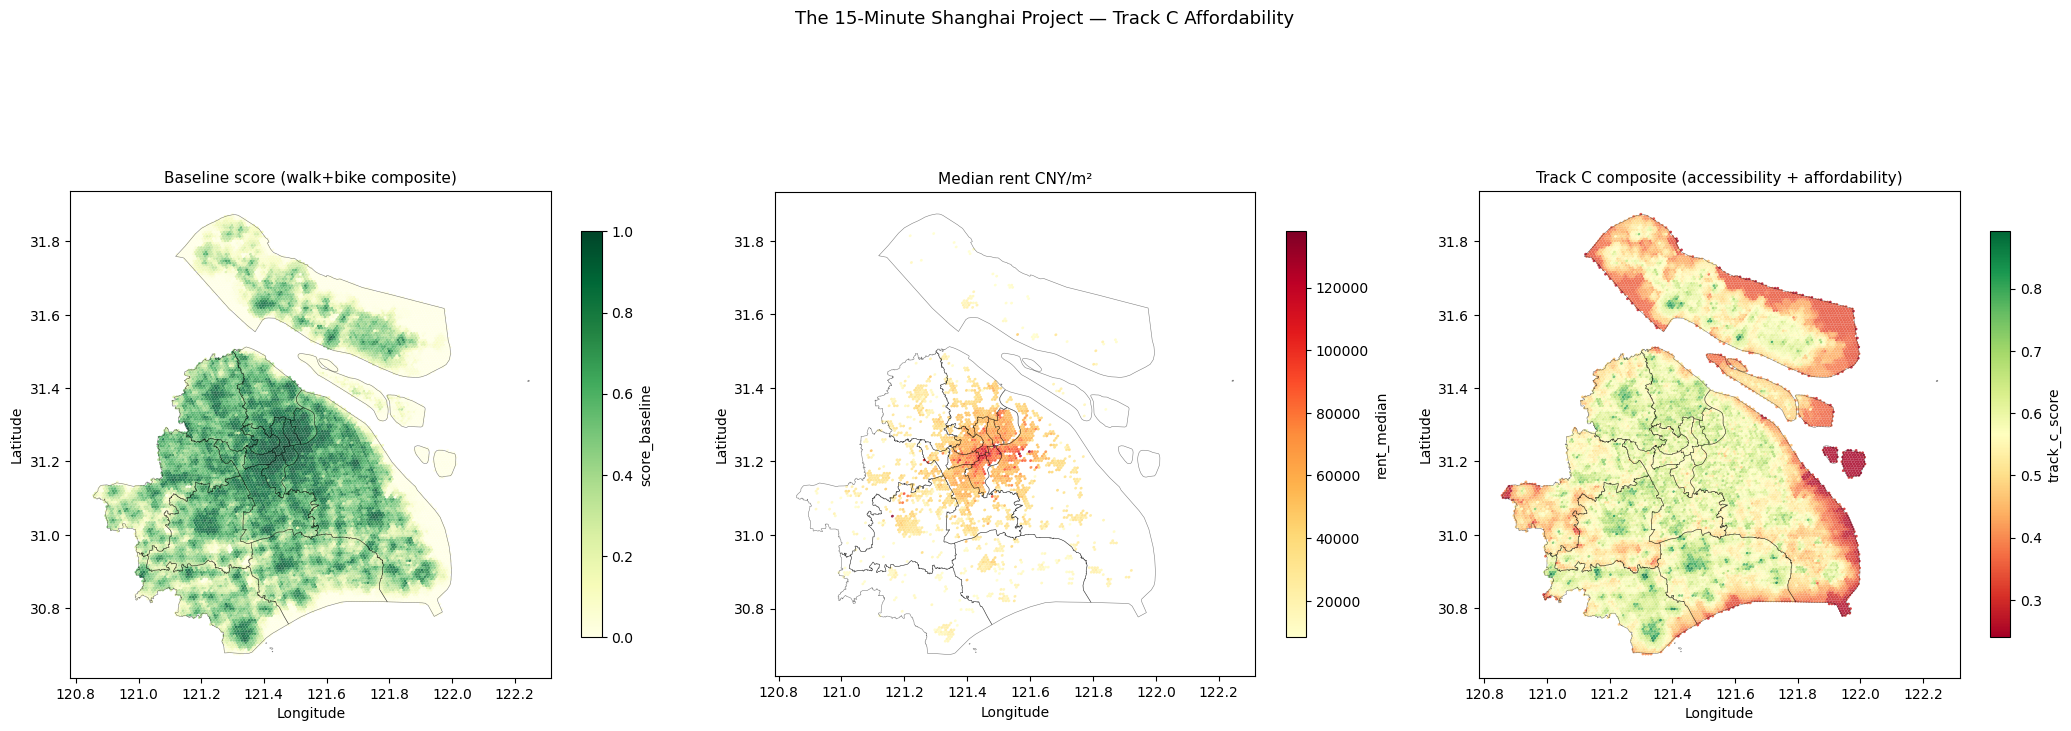

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

plot_specs = [
    ('score_baseline', 'Baseline score (walk+bike composite)', 'YlGn'),
    ('rent_median',    'Median rent CNY/m²',                  'YlOrRd'),
    ('track_c_score',  'Track C composite (accessibility + affordability)', 'RdYlGn'),
]

for ax, (col, title, cmap) in zip(axes, plot_specs):
    districts.to_crs('EPSG:4326').boundary.plot(
        ax=ax, color='black', linewidth=0.4, alpha=0.5)
    valid = hex_gdf[hex_gdf[col].notna()]
    valid.plot(column=col, ax=ax, cmap=cmap, legend=True,
               legend_kwds={'shrink': 0.55, 'label': col},
               linewidth=0, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.suptitle('The 15-Minute Shanghai Project — Track C Affordability', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(CACHE_DIR / 'scored_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()

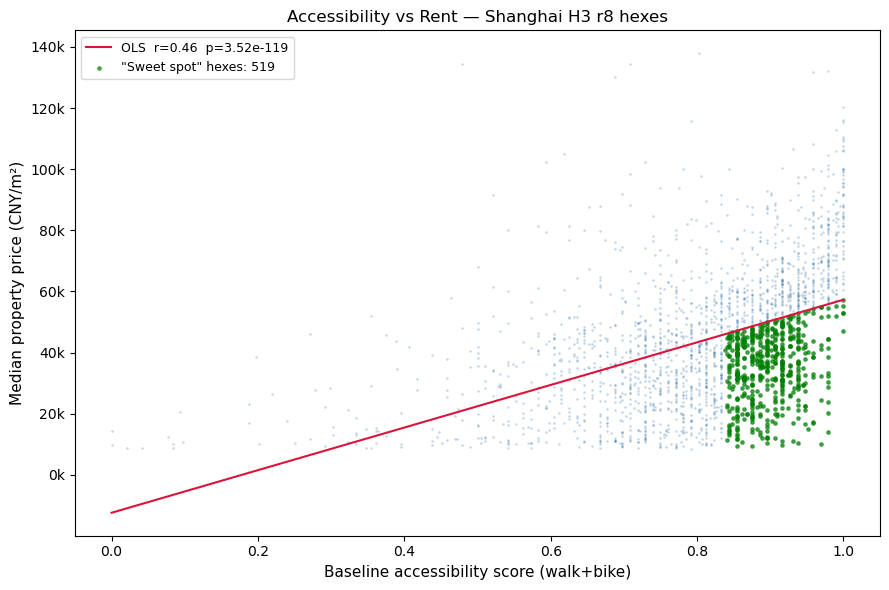

OLS: rent = 69704 × baseline_score + -12417
r = 0.462  (r² = 0.213)
→ Positive correlation: more accessible = more expensive (accessibility premium confirmed)


In [14]:
# ── Accessibility vs rent scatter (the core Track C question) ──────────────────
from scipy import stats

has_both = hex_gdf['rent_median'].notna() & hex_gdf['score_baseline'].notna()
x = hex_gdf.loc[has_both, 'score_baseline'].values
y = hex_gdf.loc[has_both, 'rent_median'].values

slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, s=3, alpha=0.35, color='steelblue', linewidths=0)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='crimson', lw=1.5,
        label=f'OLS  r={r:.2f}  p={p:.2e}')

# Shade the "sweet spot": above-median accessibility AND below-predicted rent
predicted_rent = slope * x + intercept
residual       = y - predicted_rent
sweet_mask     = (x > np.median(x)) & (residual < 0)   # accessible + below-regression
ax.scatter(x[sweet_mask], y[sweet_mask], s=6, color='green', alpha=0.6,
           label=f'"Sweet spot" hexes: {sweet_mask.sum():,}')

ax.set_xlabel('Baseline accessibility score (walk+bike)', fontsize=11)
ax.set_ylabel('Median property price (CNY/m²)', fontsize=11)
ax.set_title('Accessibility vs Rent — Shanghai H3 r8 hexes', fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
plt.tight_layout()
plt.savefig(CACHE_DIR / 'accessibility_vs_rent.png', dpi=150)
plt.show()

print(f'OLS: rent = {slope:.0f} × baseline_score + {intercept:.0f}')
print(f'r = {r:.3f}  (r² = {r**2:.3f})')
if r > 0.3:
    print('→ Positive correlation: more accessible = more expensive (accessibility premium confirmed)')
elif r > 0.1:
    print('→ Weak positive correlation: some accessibility premium but other factors dominate')
else:
    print('→ Negligible correlation: accessibility and rent are largely decoupled in Shanghai')

In [15]:
# ── Tag sweet-spot hexes in the GeoJSON ────────────────────────────────────────
# Recompute on the full hex_gdf (not just the has_both subset)
has_both_idx = hex_gdf.index[has_both]
hex_gdf['rent_residual'] = np.nan
hex_gdf.loc[has_both_idx, 'rent_residual'] = residual

# Sweet spot: top-half accessibility, below-regression rent
median_baseline = hex_gdf['score_baseline'].median()
hex_gdf['sweet_spot'] = (
    (hex_gdf['score_baseline'] > median_baseline) &
    (hex_gdf['rent_residual'].fillna(0) < 0)
).astype(int)

print(f'Sweet-spot hexes: {hex_gdf["sweet_spot"].sum():,}')

# Top-10 hexes by track_c_score (for web app recommender)
top10 = hex_gdf.nlargest(10, 'track_c_score')[['h3_id', 'score_baseline',
                                                  'rent_median', 'track_c_score']]
print('\nTop-10 hexes by Track C score:')
print(top10.to_string(index=False))

Sweet-spot hexes: 1,155

Top-10 hexes by Track C score:
          h3_id  score_baseline  rent_median  track_c_score
8830986c27fffff          0.9306   11111.1111         0.8916
88309b8c03fffff          0.9792   20312.5000         0.8913
88309b8aa7fffff          0.8958   12000.0000         0.8879
883099ccd9fffff          0.9688   10000.0000         0.8838
88309b88cdfffff          0.9062   12083.3333         0.8804
88309b8aa5fffff          0.8438   13696.2025         0.8750
88309b9933fffff          0.9479   16666.6667         0.8741
88309b1019fffff          0.8542    9574.4681         0.8737
88309b1a1bfffff          0.9583   16964.2857         0.8704
883099ccddfffff          0.9375   10461.5385         0.8695


In [16]:
# ── Re-export with sweet_spot and rent_residual columns ───────────────────────
hex_gdf = hex_gdf.copy()
float_cols = hex_gdf.select_dtypes('float').columns
hex_gdf[float_cols] = hex_gdf[float_cols].round(4)

hex_gdf.to_file(OUT_GEOJSON, driver='GeoJSON')

import os
size_mb = os.path.getsize(OUT_GEOJSON) / 1e6
print(f'Final export → {OUT_GEOJSON}')
print(f'  {len(hex_gdf):,} hexes  ·  {len(hex_gdf.columns) - 1} properties  ·  {size_mb:.1f} MB')
print(f'\nProperties: {[c for c in hex_gdf.columns if c != "geometry"]}')

Final export → cache/scored_h3.geojson
  14,227 hexes  ·  43 properties  ·  21.3 MB

Properties: ['h3_id', 'score_baseline', 'score_walk', 'score_bike', 'score_transit', 'score_car', 'score_walk_food_supplies', 'score_walk_healthcare', 'score_walk_education', 'score_walk_recreation', 'score_walk_transit', 'score_walk_daily_services', 'score_bike_food_supplies', 'score_bike_healthcare', 'score_bike_education', 'score_bike_recreation', 'score_bike_transit', 'score_bike_daily_services', 'score_transit_food_supplies', 'score_transit_healthcare', 'score_transit_education', 'score_transit_recreation', 'score_transit_transit', 'score_transit_daily_services', 'score_car_food_supplies', 'score_car_healthcare', 'score_car_education', 'score_car_recreation', 'score_car_transit', 'score_car_daily_services', 'rent_median', 'rent_count', 'rent_score', 'track_c_score', 'n_cells', 'free_amenity_score', 'clinic_ratio_score', 'school_public_score', 'employment_transit_score', 'income_rent_score', 'socia

In [17]:
# ── Generate compact JSON for the web application ────────────────────────────
# Strips geometry, maps long column names to short keys, outputs to webapp/public/data/
import json as _json, math
import pandas as pd

# CWD is the project root (15MCProject/) when Jupyter runs from there
WEBAPP_DATA = Path('webapp/public/data')
WEBAPP_DATA.mkdir(parents=True, exist_ok=True)

IND_NAMES = ['food_supplies', 'healthcare', 'education', 'recreation', 'transit', 'daily_services']
IND_SHORT  = ['food',         'health',     'edu',       'rec',        'tran',    'daily'         ]

def v(x):
    """NaN/None → None, otherwise round to 4dp."""
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    return round(float(x), 4)

def vi(x):
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    return int(x)

records = []
for _, row in hex_gdf.iterrows():
    rec = {
        'id':   row['h3_id'],
        'base': v(row['score_baseline']),
        'wk':   v(row['score_walk']),
        'bk':   v(row['score_bike']),
        'tr':   v(row['score_transit']),
        'car':  v(row['score_car']),
        **{s:          v(row[f'score_walk_{n}'])    for s, n in zip(IND_SHORT, IND_NAMES)},
        **{f'{s}_bk':  v(row[f'score_bike_{n}'])    for s, n in zip(IND_SHORT, IND_NAMES)},
        **{f'{s}_tr':  v(row[f'score_transit_{n}']) for s, n in zip(IND_SHORT, IND_NAMES)},
        **{f'{s}_car': v(row[f'score_car_{n}'])     for s, n in zip(IND_SHORT, IND_NAMES)},
        'rent': v(row['rent_median']),
        'raf':  v(row['rent_score']),
        'rc':   vi(row['rent_count']),
        'tc':   v(row['track_c_score']),
        'ss':   int(row['sweet_spot']),
        # Track C sub-indicator scores (for detail panel and recommender)
        'fa':   v(row['free_amenity_score']),
        'cr':   v(row['clinic_ratio_score']),
        'sp':   v(row['school_public_score']),
        'et':   v(row['employment_transit_score']),
        'ir':   v(row['income_rent_score']),
        'sh':   v(row['social_housing_score']),
    }
    records.append(rec)

out_path = WEBAPP_DATA / 'h3_scores.json'
with open(out_path, 'w') as f:
    _json.dump(records, f, separators=(',', ':'))

size_mb = out_path.stat().st_size / 1e6
print(f'Compact JSON → {out_path}')
print(f'  {len(records):,} hexes  ·  {len(records[0])} fields each  ·  {size_mb:.1f} MB')

Compact JSON → webapp/public/data/h3_scores.json
  14,227 hexes  ·  41 fields each  ·  7.6 MB


## Sprint 4 complete ✓

### Output: `cache/scored_h3.geojson`

| Property | Range | Notes |
|---|---|---|
| `score_baseline` | 0–1 | Walk+bike composite, 6 indicators |
| `score_walk/bike/transit/car` | 0–1 | Mode composites |
| `score_walk_{ind}` ×6 | 0–1 | Per-indicator walk scores |
| `rent_median` | CNY/m² | From Anjuke listings |
| `rent_score` | 0–1 | Inverted percentile rank (lower sale price = higher score) |
| `track_c_score` | 0–1 | 7-indicator affordability composite |
| `income_rent_score` | 0–1 | District income ÷ monthly rent, min-max (higher = more affordable) |
| `social_housing_score` | 0–1 | Proximity to nearest affordable-housing community (inverted pct rank) |
| `free_amenity_score` | 0–1 | Parks, libraries, public facilities (pct rank) |
| `clinic_ratio_score` | 0–1 | Community-clinic share vs hospitals (pct rank) |
| `school_public_score` | 0–1 | Public 学校 share vs private 培训机构 (pct rank) |
| `employment_transit_score` | 0–1 | Transit PT to nearest job cluster (pct rank) |
| `sweet_spot` | 0/1 | Above-median access + below-regression rent |

### Track C composite formula

$$\text{track\_c} = 0.25\,\text{baseline} + 0.20\,\text{rent} + 0.15\,\text{income/rent} + 0.12\,\text{employment} + 0.10\,\text{social\_housing} + 0.08\,\text{free\_amenity} + 0.05\,\text{clinic} + 0.05\,\text{school}$$

### Indicator coverage vs the brief (8 listed)

**7 implemented:** rent per m² ✓ · income/rent ratio ✓ · employment by transit ✓ ·
social-housing proximity ✓ · free public amenities ✓ · community-clinic vs hospital ✓ ·
public vs private school ✓

**1 not implemented:**
- **Food basket cost** — Shanghai food prices vary <10% across districts; only a city-wide
  estimate with minor district adjustments is possible, so per-hex granularity adds no signal.

### Data provenance notes

- **Income/rent ratio** — district-level 2024 figures assigned to hexes by point-in-polygon
  (the brief's accepted approach). Primary sources: per-capita disposable income from the
  Shanghai district statistical communiqués (上海市各区2024年国民经济和社会发展统计公报) and the
  Shanghai Municipal Bureau of Statistics (`tjj.sh.gov.cn`); average residential rent
  (¥/m²/month, H1 2024) from the E-house (易居) China R&D Institute / CRIC (克而瑞) long-term
  rental monitoring. Compiled with AI assistance, cross-checked against official anchors.
- **Social-housing proximity** — 114 affordable-housing communities (talent apartments, public
  rental, resettlement) extracted by name from the AMap 商务住宅 category of the 2023 SHP in NB01,
  already geocoded. Same source as the rest of the POI pipeline. Name-based extraction undercounts
  and skews toward 人才公寓; it is a proximity proxy, not a housing census. Nearest-community
  distance computed in EPSG:32651 via `sjoin_nearest`.

All other Track C indicators are computed at hex level from the project's own POI and listing data.

### Interpretation

- The **baseline choropleth** should show the expected concentric gradient:
  high scores in the inner ring (Jing'an, Xuhui, Huangpu), declining outward.
- The **rent map** should show a similar spatial pattern — confirming that
  accessibility is priced in.
- The **Track C score** breaks the collinearity by rewarding hexes that are
  accessible *and* affordable (low sale price, low rent-burden, near subsidised housing),
  with extra credit for free public amenities and public-institution access.
- `sweet_spot = 1` hexes (green in the scatter) are the key recommender targets:
  good 15MC access at below-market prices.

### Next: Web Application

```
Stack: React + Mapbox GL JS + deck.gl H3HexagonLayer, deployed on Vercel
Input: cache/scored_h3.geojson → serve via CDN or embed in build

Required features (from CLAUDE.md):
  ✦ H3 choropleth coloured by composite score
  ✦ Mode toggle (walk/bike/transit/car) → score_walk/bike/transit/car
  ✦ Baseline vs Track C layer toggle
  ✦ Hex-click detail panel (top amenities, metro distance, rent band)
  ✦ "Where to live" recommender (priority sliders → top-10 hexes)
  ✦ Data transparency panel (sources, date, limitations)
```